<a href="https://colab.research.google.com/github/Samikhxnn/customdataset_pytorch_classifier/blob/main/CustomDataset(classification)_Pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# import libraries and modules

In [2]:
import torch
from torch import nn  # nn provides layers and loss functions
from torch.utils.data import Dataset     # for creating custom dataset class
from torch.utils.data import DataLoader




In [3]:

import torchvision
from torchvision import transforms
from torchvision import models


In [4]:
import os
from PIL import Image

# create a custom dataset class

In [5]:
class Super(Dataset):
  def __init__(self,root,transform):
    self.root=root
    self.transform=transform



    # create class to index dictionary for giving numeric values to class names
    self.classes=sorted(os.listdir(root))
    self.class_to_idx={class_name:i  for i,class_name in enumerate(self.classes)}

    # create a list (images)  where each element is a pair of img path and label
    self.images=[]
    for class_name in self.classes:
       class_path=os.path.join(root,class_name)

       for img_name in os.listdir(class_path):
        img_path=os.path.join(class_path,img_name)

        self.images.append(      (img_path,self.class_to_idx[class_name])    )

  def __len__(self):
    return len(self.images)

  def __getitem__(self,idx):
    img_path,label=self.images[idx]

    img=Image.open(img_path).convert("RGB")

    if self.transform:
      img=self.transform(img)

    return img,label




# set up train and test transforms

In [6]:
train_transform=transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomCrop(224,padding=5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])
test_transform=transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# create instance of the class

In [7]:
# create instance of the class
train_dataset=Super(root='/content/drive/MyDrive/super/train',transform=train_transform)
test_dataset=Super(root='/content/drive/MyDrive/super/test',transform=test_transform)

# prepare DataLoader

In [8]:
train_dataloader=DataLoader(train_dataset,batch_size=10,shuffle=True)
test_dataloader=DataLoader(test_dataset,batch_size=5)

# loading a pretrained Model

In [9]:
model=models.vgg16(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [10]:
# freezing feature layer parameters
for param in model.features.parameters():
  param.requires_grad=False

# to sure classifier layer is learning
for param in model.classifier.parameters():
  param.requires_grad=True

In [11]:
model.classifier

Sequential(
  (0): Linear(in_features=25088, out_features=4096, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=4096, out_features=4096, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout(p=0.5, inplace=False)
  (6): Linear(in_features=4096, out_features=1000, bias=True)
)

In [12]:
# updating classifier layer according to our data
model.classifier=nn.Sequential(
    nn.Linear(25088,1000),
    nn.ReLU(),
    nn.Linear(1000,300),
    nn.ReLU(),
    nn.Linear(300,3)
)

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Set up loss function and optimizer

In [14]:
loss_func=nn.CrossEntropyLoss()
o=torch.optim.Adam(params=model.classifier.parameters(),
                   lr=0.0001
                   )

# training Loop

In [17]:
epochs=101

for epoch in range(epochs):
  t_loss=0
  for x,y in train_dataloader:
    x, y = x.to(device), y.to(device)
    o.zero_grad()

    y_logits=model(x)
    loss=loss_func(y_logits,y)

    t_loss+=loss

    #o.zero_grad()
    loss.backward()
    o.step()

  if epoch%10==0:
    print("epoch",epoch)
    print("avg loss per batch : ",t_loss/len(train_dataloader))

epoch 0
avg loss per batch :  tensor(0.4429, device='cuda:0', grad_fn=<DivBackward0>)
epoch 10
avg loss per batch :  tensor(0.0086, device='cuda:0', grad_fn=<DivBackward0>)
epoch 20
avg loss per batch :  tensor(0.0090, device='cuda:0', grad_fn=<DivBackward0>)
epoch 30
avg loss per batch :  tensor(0.0081, device='cuda:0', grad_fn=<DivBackward0>)
epoch 40
avg loss per batch :  tensor(0.0031, device='cuda:0', grad_fn=<DivBackward0>)
epoch 50
avg loss per batch :  tensor(0.0096, device='cuda:0', grad_fn=<DivBackward0>)
epoch 60
avg loss per batch :  tensor(0.0224, device='cuda:0', grad_fn=<DivBackward0>)
epoch 70
avg loss per batch :  tensor(0.0082, device='cuda:0', grad_fn=<DivBackward0>)
epoch 80
avg loss per batch :  tensor(0.0046, device='cuda:0', grad_fn=<DivBackward0>)


KeyboardInterrupt: 

# testing loop

In [18]:
model.eval()

with torch.no_grad():



  total_correct=0
  total_sample=0
  for x,y in test_dataloader:
    x, y = x.to(device), y.to(device)
    y_logits=model(x)
    y_prob=torch.softmax(y_logits,dim=1)
    y_class=torch.argmax(y_prob,dim=1)

    total_correct+=(y==y_class).sum().item()
    total_sample+=y.size(0)


  print("accuracy",total_correct*100/total_sample)


accuracy 89.44444444444444


In [19]:
torch.save(model.state_dict(),"super_best_model.pth")

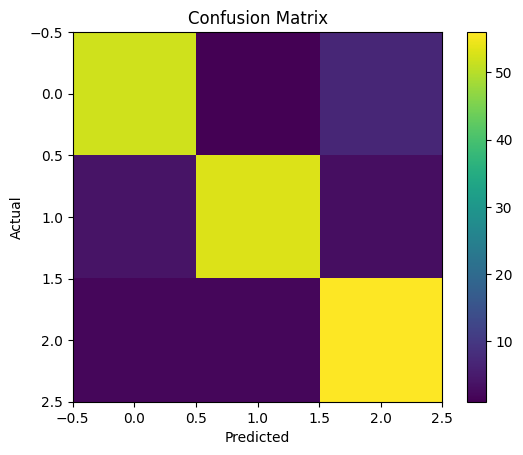

In [20]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

all_preds=[]
all_labels=[]

model.eval()

with torch.no_grad():
    for x,y in test_dataloader:
        x,y=x.to(device),y.to(device)

        logits=model(x)
        preds=torch.argmax(logits,dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

cm=confusion_matrix(all_labels,all_preds)

plt.imshow(cm)
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

               precision    recall  f1-score   support

black panther       0.90      0.87      0.88        60
  ghost rider       0.95      0.88      0.91        60
green lantern       0.85      0.93      0.89        60

     accuracy                           0.89       180
    macro avg       0.90      0.89      0.89       180
 weighted avg       0.90      0.89      0.89       180



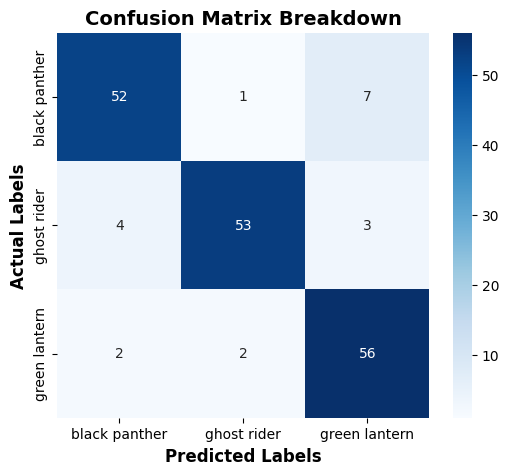

In [21]:
import seaborn as sns
from sklearn.metrics import classification_report

# Print the exact text breakdown first
print(classification_report(all_labels, all_preds, target_names=train_dataset.classes))

# Plot a much cleaner, labeled heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=train_dataset.classes,
            yticklabels=train_dataset.classes)
plt.xlabel('Predicted Labels', fontsize=12, fontweight='bold')
plt.ylabel('Actual Labels', fontsize=12, fontweight='bold')
plt.title('Confusion Matrix Breakdown', fontsize=14, fontweight='bold')
plt.show()

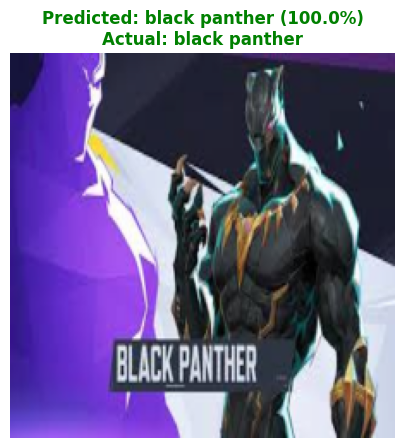

In [64]:
import numpy as np
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():
    # 1. Grab a sample
    img, label = test_dataset[22]

    # 2. Run inference
    x = img.unsqueeze(0).to(device)
    logits = model(x)
    probs = torch.softmax(logits, dim=1)
    pred = torch.argmax(probs, dim=1)
    confidence = probs.max().item() * 100

    # 3. UN-NORMALIZE the image for plotting
    img_np = img.permute(1, 2, 0).cpu().numpy()
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img_np = std * img_np + mean  # Denormalize
    img_np = np.clip(img_np, 0, 1) # Keep pixels in clean 0-1 range

    # 4. Map the numeric prediction back to the character name
    pred_classname = train_dataset.classes[pred.item()]
    true_classname = train_dataset.classes[label]

    # 5. Plot beautifully
    plt.figure(figsize=(5, 5))
    plt.imshow(img_np)
    color = "green" if pred.item() == label else "red"
    plt.title(f"Predicted: {pred_classname} ({confidence:.1f}%)\nActual: {true_classname}",
              color=color, fontsize=12, fontweight='bold')
    plt.axis('off')
    plt.show()

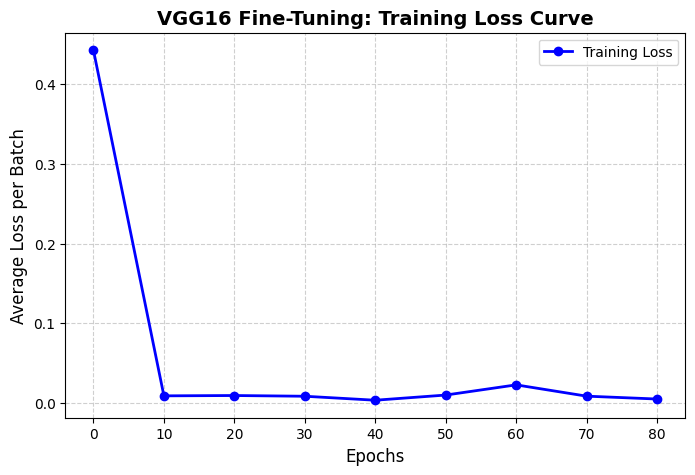

In [65]:
import matplotlib.pyplot as plt

epochs = [0, 10, 20, 30, 40, 50, 60, 70, 80]
losses = [0.4429, 0.0086, 0.0090, 0.0081, 0.0031, 0.0096, 0.0224, 0.0082, 0.0046]

plt.figure(figsize=(8, 5))
plt.plot(epochs, losses, marker='o', color='b', linestyle='-', linewidth=2, label='Training Loss')

plt.title('VGG16 Fine-Tuning: Training Loss Curve', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Average Loss per Batch', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Save the plot directly to Colab's files
plt.savefig('loss_curve.png', dpi=300, bbox_inches='tight')
plt.show()